# ScanNet Preprocessing Pipeline

Downloads ScanNet `.sens` + `.txt` files, extracts evenly-spaced frames,
center-crops to 256x256, saves as paired `_rgb.pt`/`_depth.pt` tensors,
computes normalization stats, and packages for Google Drive upload.

**Requirements:**
- Colab with High RAM runtime (12 CPU cores, no GPU needed)
- Google Drive mounted for final upload

**Disk strategy:** Each `.sens` file is 100-200MB. We use a strict
download-extract-delete micro-loop per scene to avoid disk exhaustion.
Crash recovery via `.done` marker files.

## 1. Install & Imports

In [1]:
!pip install -q tqdm pypng

import glob
import hashlib
import json
import math
import multiprocessing
import os
import random
import re
import shutil
import struct
import subprocess
import sys
import time
import zlib
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

## 2. Configuration

In [2]:
BASE_OUT_DIR     = '/content/scannet_pretrain_256'
TMP_DIR          = '/content/scannet_tmp'
DRIVE            = '/content/drive/MyDrive/datasets'

FRAMES_PER_SCENE = 85
MIN_FRAMES       = 10
TARGET_SIZE      = 256
MAX_WORKERS      = os.cpu_count()

# Blur rejection: Laplacian variance below this threshold indicates
# motion blur, which causes RGB-depth misalignment in handheld scans.
# Blurry frames teach fusion layers that cross-modal edges are unreliable.
# Set to 0 to disable blur rejection.
BLUR_THRESHOLD   = 20.0
# How many frames to search around a blurry sample before giving up
BLUR_SEARCH_WINDOW = 5

os.makedirs(BASE_OUT_DIR, exist_ok=True)
os.makedirs(TMP_DIR, exist_ok=True)
os.makedirs(DRIVE, exist_ok=True)

print(f'Output:  {BASE_OUT_DIR}')
print(f'Temp:    {TMP_DIR}')
print(f'Drive:   {DRIVE}')
print(f'Blur threshold: {BLUR_THRESHOLD} (0=disabled)')
print(f'Max workers count: {MAX_WORKERS}')

Output:  /content/scannet_pretrain_256
Temp:    /content/scannet_tmp
Drive:   /content/drive/MyDrive/data
Blur threshold: 20.0 (0=disabled)
Max workers count: 8


## 3. Scene Type Mapping

In [3]:
# 20 canonical scene types (no Misc). Order defines class indices 0-19.
SCANNET_SCENE_TYPES = [
    'apartment',
    'bathroom',
    'bedroom',
    'bookstore_library',
    'classroom',
    'closet',
    'computer_cluster',
    'conference_room',
    'copy_mail_room',
    'dining_room',
    'game_room',
    'gym',
    'hallway',
    'kitchen',
    'laundry_room',
    'living_room',
    'lobby',
    'office',
    'stairs',
    'storage_basement_garage',
]

# Aliases for raw sceneType strings that don't match canonical names.
# Populated after running Cell 14 (metadata scan).
# Keys: lowercase stripped raw sceneType -> Values: canonical name
SCENE_TYPE_ALIASES = {
    # Built from actual ScanNet metadata (Cell 14 output).
    # Raw sceneType strings that don't normalize via simple lowering + underscore.
    'bedroom / hotel': 'bedroom',
    'bedroom/hotel': 'bedroom',
    'living room / lounge': 'living_room',
    'living room/lounge': 'living_room',
    'bookstore / library': 'bookstore_library',
    'bookstore/library': 'bookstore_library',
    'copy/mail room': 'copy_mail_room',
    'copy / mail room': 'copy_mail_room',
    'storage/basement/garage': 'storage_basement_garage',
    'storage / basement / garage': 'storage_basement_garage',
    'computercluster': 'computer_cluster',
    'computer cluster': 'computer_cluster',
    'misc.': None,  # Explicit skip
    'misc': None,
}

print(f'{len(SCANNET_SCENE_TYPES)} scene types defined.')

20 scene types defined.


## 4. Mount Drive + Setup Tools

In [4]:
from google.colab import drive
# Clear stale mount if runtime was partially reset
if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    !fusermount -u /content/drive 2>/dev/null || true
    !rm -rf /content/drive
drive.mount('/content/drive')

TOOLS_DIR = '/content/scannet_tools'
os.makedirs(TOOLS_DIR, exist_ok=True)

# Download ScanNet download script (hosted by TUM, not on GitHub)
subprocess.run([
    'wget', '-q', '-O', os.path.join(TOOLS_DIR, 'download-scannet.py'),
    'http://kaldir.vc.cit.tum.de/scannet/download-scannet.py'
], check=True)

# Download SensorData.py for parsing .sens files
subprocess.run([
    'wget', '-q', '-O', os.path.join(TOOLS_DIR, 'SensorData.py'),
    'https://raw.githubusercontent.com/ScanNet/ScanNet/master/SensReader/python/SensorData.py'
], check=True)

# SensorData.py is Python 2 — patch for Python 3 compatibility
# Line-by-line patching to avoid silent failures from quote mismatches
_sd_path = os.path.join(TOOLS_DIR, 'SensorData.py')
with open(_sd_path, 'r') as f:
    _sd_lines = f.readlines()

_patched = 0
for _i, _line in enumerate(_sd_lines):
    _orig = _line

    # 1. Fix print statements: "print x" -> "print(x)"
    _match = re.match(r"^(\s*)print (.+)$", _line.rstrip())
    if _match and 'print(' not in _line:
        _sd_lines[_i] = f"{_match.group(1)}print({_match.group(2)})\n"

    # 2. Fix bytes/str join: struct.unpack('c') returns bytes in Py3
    if ".join(struct.unpack(" in _line and "b'" not in _line.split('join')[0]:
        _sd_lines[_i] = _sd_lines[_i].replace("''.join(", "b''.join(")

    # 3. Fix np.fromstring -> np.frombuffer
    if 'np.fromstring' in _sd_lines[_i]:
        _sd_lines[_i] = _sd_lines[_i].replace('np.fromstring', 'np.frombuffer')

    if _sd_lines[_i] != _orig:
        _patched += 1

with open(_sd_path, 'w') as f:
    f.writelines(_sd_lines)

assert _patched >= 7, f'Expected at least 7 patches, only applied {_patched}'
print(f'SensorData.py patched for Python 3 ({_patched} lines fixed)')

# Add tools dir to sys.path so SensorData can be imported
if TOOLS_DIR not in sys.path:
    sys.path.insert(0, TOOLS_DIR)

# Download official train/val split files
SPLITS_DIR = os.path.join(TOOLS_DIR, 'splits')
os.makedirs(SPLITS_DIR, exist_ok=True)

for split_file in ['scannetv2_train.txt', 'scannetv2_val.txt']:
    subprocess.run([
        'wget', '-q', '-O', os.path.join(SPLITS_DIR, split_file),
        f'https://raw.githubusercontent.com/ScanNet/ScanNet/master/Tasks/Benchmark/{split_file}'
    ], check=True)

# Load split scene IDs
def load_split_ids(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

train_scene_ids = load_split_ids(os.path.join(SPLITS_DIR, 'scannetv2_train.txt'))
val_scene_ids   = load_split_ids(os.path.join(SPLITS_DIR, 'scannetv2_val.txt'))

print(f'Train scenes: {len(train_scene_ids)}')
print(f'Val scenes:   {len(val_scene_ids)}')
print(f'Total:        {len(train_scene_ids) + len(val_scene_ids)}')
import SensorData  # noqa: downloaded above, must import after sys.path setup

print(f'SensorData.py: {os.path.exists(os.path.join(TOOLS_DIR, "SensorData.py"))}')

Mounted at /content/drive
SensorData.py patched for Python 3 (8 lines fixed)
Train scenes: 1201
Val scenes:   312
Total:        1513
SensorData.py: True


## 5. Download .txt Metadata (Lightweight)

Batch-download all `.txt` metadata files. These are tiny (a few KB each)
and safe to batch.

In [5]:
TXT_DIR = os.path.join(TMP_DIR, 'txt_metadata')
os.makedirs(TXT_DIR, exist_ok=True)

all_scene_ids = train_scene_ids + val_scene_ids
print(f'Downloading .txt metadata for {len(all_scene_ids)} scenes...')

downloaded = 0
skipped = 0
for scene_id in tqdm(all_scene_ids, desc='Downloading .txt'):
    # download-scannet.py saves to TXT_DIR/scans/<scene_id>/<scene_id>.txt
    txt_out = os.path.join(TXT_DIR, 'scans', scene_id, f'{scene_id}.txt')
    if os.path.exists(txt_out):
        skipped += 1
        continue
    cmd = [
        'python3', os.path.join(TOOLS_DIR, 'download-scannet.py'),
        '-o', TXT_DIR,
        '--id', scene_id,
        '--type', '.txt',
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60,
                            input='y\ny\n')
    if result.returncode != 0:
        print(f'WARNING: Failed to download {scene_id}.txt: {result.stderr[:200]}')
    else:
        downloaded += 1

print(f'Downloaded: {downloaded}, Skipped (existing): {skipped}')

Downloaded: 1501, Skipped (existing): 12


## 6. Parse Scene Metadata

In [6]:
def parse_scene_metadata(txt_path):
    """Parse <scene_id>.txt metadata file.

    Format: key = value (split on first '=', strip whitespace).
    Returns dict of field -> value. Key field: 'sceneType'.
    """
    metadata = {}
    with open(txt_path) as f:
        for line in f:
            line = line.strip()
            if '=' not in line:
                continue
            key, value = line.split('=', 1)
            metadata[key.strip()] = value.strip()
    return metadata


def normalize_scene_type(scene_type_str):
    """Normalize raw sceneType string to canonical class name.

    Lowercases, strips whitespace, replaces spaces with underscores,
    and checks SCENE_TYPE_ALIASES. Returns None if the type is Misc
    or unrecognized (scene should be skipped).
    """
    raw = scene_type_str.strip().lower()

    # Check aliases first
    if raw in SCENE_TYPE_ALIASES:
        return SCENE_TYPE_ALIASES[raw]

    # Try direct match with underscores
    canonical = raw.replace(' ', '_')
    if canonical in SCANNET_SCENE_TYPES:
        return canonical

    # Try slash variations: "bedroom / hotel" -> "bedroom"
    # Also "living room / lounge" -> "living_room"
    if '/' in raw:
        parts = [p.strip().replace(' ', '_') for p in raw.split('/')]
        for part in parts:
            if part in SCANNET_SCENE_TYPES:
                return part

    return None


# Quick test
print('normalize_scene_type tests:')
for test in ['Bathroom', 'bedroom / hotel', 'Living room / Lounge', 'Misc', 'Office']:
    print(f'  {test!r:30s} -> {normalize_scene_type(test)}')

normalize_scene_type tests:
  'Bathroom'                     -> bathroom
  'bedroom / hotel'              -> bedroom
  'Living room / Lounge'         -> living_room
  'Misc'                         -> None
  'Office'                       -> office


## 7. Pre-Processing Metadata Scan

Parse ALL downloaded `.txt` files. Print every unique raw `sceneType`
string with counts. Identify which map to the 20 types, which need
aliases, which will be skipped.

**Review the output below and update `SCENE_TYPE_ALIASES` in Cell 6
before proceeding.**

In [7]:
raw_type_counts = Counter()
mapped_counts = Counter()
unmapped_types = Counter()
scenes_with_metadata = {}

for scene_id in all_scene_ids:
    # download-scannet.py saves to TXT_DIR/scans/<scene_id>/<scene_id>.txt
    txt_candidates = [
        os.path.join(TXT_DIR, 'scans', scene_id, f'{scene_id}.txt'),
        os.path.join(TXT_DIR, scene_id, f'{scene_id}.txt'),
        os.path.join(TXT_DIR, f'{scene_id}.txt'),
    ]
    txt_path = None
    for candidate in txt_candidates:
        if os.path.exists(candidate):
            txt_path = candidate
            break
    if txt_path is None:
        print(f'WARNING: No .txt metadata for {scene_id}')
        continue

    meta = parse_scene_metadata(txt_path)
    raw_type = meta.get('sceneType', '')
    raw_type_counts[raw_type] += 1

    canonical = normalize_scene_type(raw_type)
    if canonical:
        mapped_counts[canonical] += 1
        scenes_with_metadata[scene_id] = (canonical, txt_path)
    else:
        unmapped_types[raw_type] += 1

print('=== All unique raw sceneType strings ===')
for raw_type, count in sorted(raw_type_counts.items(), key=lambda x: -x[1]):
    canonical = normalize_scene_type(raw_type)
    status = f'-> {canonical}' if canonical else '** SKIPPED **'
    print(f'  {count:4d}  {raw_type!r:40s} {status}')

print(f'\n=== Summary ===')
print(f'Total scenes in splits:    {len(all_scene_ids)}')
print(f'Successfully mapped:       {len(scenes_with_metadata)}')
print(f'Will be skipped:           {sum(unmapped_types.values())}')
print(f'Expected output frames:    ~{len(scenes_with_metadata) * FRAMES_PER_SCENE:,}')

if unmapped_types:
    print(f'\n=== Unmapped types (need aliases or will be skipped) ===')
    for raw_type, count in sorted(unmapped_types.items(), key=lambda x: -x[1]):
        print(f'  {count:4d}  {raw_type!r}')

print(f'\n=== Mapped class distribution ===')
for cls, count in sorted(mapped_counts.items()):
    print(f'  {count:4d}  {cls}')

=== All unique raw sceneType strings ===
   273  'Bedroom / Hotel'                        -> bedroom
   224  'Living room / Lounge'                   -> living_room
   212  'Bathroom'                               -> bathroom
   173  'Office'                                 -> office
   111  'Conference Room'                        -> conference_room
   108  'Kitchen'                                -> kitchen
    67  'Bookstore / Library'                    -> bookstore_library
    54  'Lobby'                                  -> lobby
    50  'Copy/Mail Room'                         -> copy_mail_room
    40  'Apartment'                              -> apartment
    37  'Classroom'                              -> classroom
    35  'Misc.'                                  ** SKIPPED **
    32  'Hallway'                                -> hallway
    20  'Laundry Room'                           -> laundry_room
    19  'Storage/Basement/Garage'                -> storage_basement_garage
    

## 8. Frame Extraction Helpers

In [8]:
def laplacian_variance(rgb_frame):
    """Compute variance of Laplacian as a sharpness measure.

    Low values indicate motion blur. ScanNet is handheld video, so frames
    captured during fast camera motion have RGB-depth misalignment that
    harms fusion layer pretraining.

    Uses OpenCV's optimized C++ Laplacian instead of scipy.signal.convolve2d
    for ~50-100x speedup on the 1296x968 raw frames.

    Args:
        rgb_frame: HxWx3 uint8 numpy array.

    Returns:
        float: Variance of the Laplacian (higher = sharper).
    """
    gray = cv2.cvtColor(rgb_frame, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def extract_frames_from_sens(sens_path, output_dir, scene_id,
                             num_frames=66, target_size=256,
                             blur_threshold=100.0, blur_search_window=5):
    """Extract evenly-spaced frames from a .sens file with blur rejection.

    For each selected frame index, computes the Laplacian variance (sharpness).
    If below blur_threshold, searches nearby frames (within blur_search_window)
    for a sharp replacement. This preserves spatial diversity while avoiding
    motion-blurred frames that cause RGB-depth misalignment.

    Asserts depth_shift == 1000.0 (sanity check: raw uint16 values are mm).
    Saves RGB as uint8 [3, H, W] and depth as uint16 [1, H, W].

    Returns:
        tuple: (frames_extracted, blur_replaced, blur_dropped) where
            blur_replaced = blurry frames that found a sharp neighbor,
            blur_dropped = blurry frames with no sharp neighbor (sample lost).

    Raises:
        RuntimeError: On corrupt/unreadable .sens files or too few frames.
    """

    try:
        sd = SensorData.SensorData(sens_path)
    except Exception as e:
        raise RuntimeError(f'Failed to parse {sens_path}: {e}') from e

    # Sanity check: depth_shift should be 1000.0 (raw values are mm)
    if hasattr(sd, 'depth_shift') and sd.depth_shift != 1000.0:
        print(f'WARNING: {scene_id} has depth_shift={sd.depth_shift} (expected 1000.0)')
    assert hasattr(sd, 'depth_shift') and sd.depth_shift == 1000.0, (
        f'{scene_id}: depth_shift={getattr(sd, "depth_shift", "MISSING")} != 1000.0'
    )

    total_frames = len(sd.frames)
    if total_frames < MIN_FRAMES:
        raise RuntimeError(
            f'{scene_id}: only {total_frames} frames (min={MIN_FRAMES}), skipping'
        )

    # Select evenly-spaced frame indices
    n_sample = min(num_frames, total_frames)
    indices = np.linspace(0, total_frames - 1, n_sample, dtype=int)

    os.makedirs(output_dir, exist_ok=True)
    extracted = 0
    blur_replaced = 0
    blur_dropped = 0

    for target_idx in indices:
        # Try the target frame first, then search nearby if blurry
        candidates = [target_idx]
        if blur_threshold > 0:
            for offset in range(1, blur_search_window + 1):
                if target_idx + offset < total_frames:
                    candidates.append(target_idx + offset)
                if target_idx - offset >= 0:
                    candidates.append(target_idx - offset)

        frame_saved = False
        target_was_blurry = False
        for idx in candidates:
            frame = sd.frames[idx]

            # Decompress color (JPEG) -> RGB HxWx3 uint8
            try:
                color_img = frame.decompress_color(sd.color_compression_type)
            except Exception:
                continue
            if color_img is None:
                continue

            # Blur rejection check (on full-res RGB for accuracy)
            if blur_threshold > 0:
                sharpness = laplacian_variance(color_img)
                if sharpness < blur_threshold:
                    if idx == target_idx:
                        target_was_blurry = True
                    continue  # Try next candidate

            # Decompress depth -> raw bytes -> HxW uint16
            try:
                depth_data = frame.decompress_depth(sd.depth_compression_type)
                depth_img = np.frombuffer(depth_data, dtype=np.uint16).reshape(
                    sd.depth_height, sd.depth_width
                )
            except Exception:
                continue

            # SPATIAL ALIGNMENT + RESIZE TO TARGET SIZE
            # SensorData.py returns raw unaligned images -- RGB at 1296x968 and
            # depth at 640x480 with different intrinsics and a ~3.8cm physical
            # offset (ScanNet GitHub Issues #28, #69, #101).
            #
            # Step 1: Resize RGB to depth resolution (640x480) for FOV alignment
            # Step 2: Resize both to target_size x target_size (256x256) to
            #         preserve full spatial coverage for scene classification
            depth_h, depth_w = depth_img.shape[:2]
            if color_img.shape[:2] != (depth_h, depth_w):
                color_img = cv2.resize(
                    color_img, (depth_w, depth_h),
                    interpolation=cv2.INTER_AREA,
                )

            # Resize both to target size (preserves full scene context)
            color_crop = cv2.resize(
                color_img, (target_size, target_size),
                interpolation=cv2.INTER_AREA,
            )
            depth_crop = cv2.resize(
                depth_img, (target_size, target_size),
                interpolation=cv2.INTER_NEAREST,  # nearest for depth to avoid interpolation artifacts
            )

            # Convert to tensors: RGB [3, H, W] uint8, depth [1, H, W] uint16
            rgb_tensor = torch.from_numpy(
                color_crop.transpose(2, 0, 1).copy()
            ).to(torch.uint8)
            depth_tensor = torch.from_numpy(
                depth_crop[np.newaxis, :, :].copy()
            ).to(torch.uint16)

            # Save tensors
            prefix = f'{scene_id}_f{idx:05d}'
            torch.save(rgb_tensor, os.path.join(output_dir, f'{prefix}_rgb.pt'))
            torch.save(depth_tensor, os.path.join(output_dir, f'{prefix}_depth.pt'))
            extracted += 1
            frame_saved = True
            if target_was_blurry:
                blur_replaced += 1
            break  # Got a sharp frame for this sample point

        if not frame_saved and target_was_blurry:
            blur_dropped += 1

    return extracted, blur_replaced, blur_dropped

## 9. Download-Extract-Delete Micro-Loop

**CRITICAL: Colab disk constraint.** Raw `.sens` files are 100-200MB each.
Each worker handles the full lifecycle for one scene:
download -> extract -> delete.

Pool capped at `MAX_WORKERS=4` to limit concurrent disk usage (~800MB peak)
and avoid server rate-limiting.

In [9]:
def process_scene(args):
    """Full download-extract-delete micro-loop for one scene.

    args = (scene_id, split_name, txt_dir, output_base_dir,
            sens_tmp_dir, num_frames, target_size)

    Returns dict with keys: scene_id, class_name, num_frames,
    status ('ok'/'skipped'/'error'), error_msg (if error).
    """

    scene_id, split_name, txt_dir, output_base_dir, sens_tmp_dir, \
        num_frames, target_size = args

    result = {
        'scene_id': scene_id,
        'class_name': None,
        'num_frames': 0,
        'blur_replaced': 0,
        'blur_dropped': 0,
        'status': 'error',
        'error_msg': None,
    }

    done_marker = os.path.join(output_base_dir, f'{scene_id}.done')

    # (1) Check .done marker -> skip if present
    if os.path.exists(done_marker):
        result['status'] = 'skipped'
        return result

    # Parse metadata to get scene type
    # download-scannet.py may nest files in various subdirectory structures
    # (e.g., txt_dir/scene0000_00.txt, txt_dir/scene0000_00/scene0000_00.txt,
    #  txt_dir/scans/scene0000_00/scene0000_00.txt)
    txt_candidates = [
        os.path.join(txt_dir, f'{scene_id}.txt'),
        os.path.join(txt_dir, scene_id, f'{scene_id}.txt'),
    ]
    # Also search recursively as fallback
    txt_candidates += glob.glob(
        os.path.join(txt_dir, '**', f'{scene_id}.txt'), recursive=True
    )
    txt_path = None
    for candidate in txt_candidates:
        if os.path.exists(candidate):
            txt_path = candidate
            break
    if txt_path is None:
        result['error_msg'] = 'No .txt metadata found'
        return result

    meta = parse_scene_metadata(txt_path)
    raw_type = meta.get('sceneType', '')
    canonical = normalize_scene_type(raw_type)
    if canonical is None:
        result['status'] = 'skipped'
        result['error_msg'] = f'Unrecognized sceneType: {raw_type!r}'
        return result

    result['class_name'] = canonical
    scene_out_dir = os.path.join(output_base_dir, split_name, canonical)

    # (2) If no marker but partial files exist, wipe and re-process
    existing_files = glob.glob(os.path.join(scene_out_dir, f'{scene_id}_f*_*.pt'))
    if existing_files:
        for f in existing_files:
            os.remove(f)

    # (3) Download .sens via subprocess with retry + exponential backoff
    sens_download_dir = os.path.join(sens_tmp_dir, scene_id)
    os.makedirs(sens_download_dir, exist_ok=True)
    # download-scannet.py saves to <out>/scans/<scene_id>/<scene_id>.sens
    sens_path = os.path.join(sens_download_dir, 'scans', scene_id, f'{scene_id}.sens')

    max_retries = 3
    for attempt in range(max_retries):
        cmd = [
            'python3', os.path.join('/content/scannet_tools', 'download-scannet.py'),
            '-o', sens_download_dir,
            '--id', scene_id,
            '--type', '.sens',
        ]
        try:
            dl_result = subprocess.run(
                cmd, capture_output=True, text=True, timeout=600,
                input='y\ny\n',
            )
            # Check if .sens file exists (download script may put it in subdir)
            if not os.path.exists(sens_path):
                # Try other possible locations
                for alt in [
                    os.path.join(sens_download_dir, scene_id, f'{scene_id}.sens'),
                    os.path.join(sens_download_dir, f'{scene_id}.sens'),
                ]:
                    if os.path.exists(alt):
                        sens_path = alt
                        break
            if os.path.exists(sens_path):
                break
        except subprocess.TimeoutExpired:
            pass

        if attempt < max_retries - 1:
            time.sleep(2 ** (attempt + 1))  # Exponential backoff

    if not os.path.exists(sens_path):
        result['error_msg'] = 'Failed to download .sens after retries'
        # Cleanup
        shutil.rmtree(sens_download_dir, ignore_errors=True)
        return result

    # (4) Extract frames with 120s timeout
    try:
        n_extracted, n_blur_replaced, n_blur_dropped = extract_frames_from_sens(
            sens_path, scene_out_dir, scene_id,
            num_frames=num_frames, target_size=target_size,
            blur_threshold=BLUR_THRESHOLD,
            blur_search_window=BLUR_SEARCH_WINDOW,
        )
        result['num_frames'] = n_extracted
        result['blur_replaced'] = n_blur_replaced
        result['blur_dropped'] = n_blur_dropped
    except Exception as e:
        result['error_msg'] = str(e)[:200]
        # Cleanup partial output
        partial = glob.glob(os.path.join(scene_out_dir, f'{scene_id}_f*_*.pt'))
        for f in partial:
            os.remove(f)
        shutil.rmtree(sens_download_dir, ignore_errors=True)
        return result

    # (5) Write .done marker
    with open(done_marker, 'w') as f:
        f.write(f'{canonical}\n{n_extracted}\n{n_blur_replaced} blur_replaced\n{n_blur_dropped} blur_dropped\n')
    result['status'] = 'ok'

    # (6) Delete .sens file immediately
    shutil.rmtree(sens_download_dir, ignore_errors=True)

    return result

# Build task list: ONLY scene IDs from train + val splits
train_set = set(train_scene_ids)
val_set = set(val_scene_ids)

tasks = []
for scene_id in train_scene_ids:
    tasks.append((
        scene_id, 'train', TXT_DIR, BASE_OUT_DIR, TMP_DIR,
        FRAMES_PER_SCENE, TARGET_SIZE
    ))
for scene_id in val_scene_ids:
    tasks.append((
        scene_id, 'val', TXT_DIR, BASE_OUT_DIR, TMP_DIR,
        FRAMES_PER_SCENE, TARGET_SIZE
    ))

print(f'Total tasks: {len(tasks)}')

# Process with multiprocessing pool
progress_path = os.path.join(BASE_OUT_DIR, 'progress.json')
results_log = []
counts = Counter()  # ok, skipped, error
running_frames = 0
running_blur_replaced = 0
running_blur_dropped = 0

with multiprocessing.Pool(MAX_WORKERS) as pool:
    pbar = tqdm(total=len(tasks), desc='Processing scenes')
    for result in pool.imap_unordered(process_scene, tasks):
        results_log.append(result)
        counts[result['status']] += 1
        running_frames += result.get('num_frames', 0)
        running_blur_replaced += result.get('blur_replaced', 0)
        running_blur_dropped += result.get('blur_dropped', 0)

        # Update progress bar
        pbar.set_postfix(
            ok=counts['ok'], skip=counts['skipped'], err=counts['error'],
            frames=running_frames, blur_fix=running_blur_replaced, blur_lost=running_blur_dropped,
        )
        pbar.update(1)

        # Write progress.json from main process only
        if len(results_log) % 10 == 0:
            with open(progress_path, 'w') as f:
                json.dump({
                    'completed': len(results_log),
                    'total': len(tasks),
                    'ok': counts['ok'],
                    'skipped': counts['skipped'],
                    'error': counts['error'],
                }, f)
    pbar.close()

# Final progress write
with open(progress_path, 'w') as f:
    json.dump({
        'completed': len(results_log),
        'total': len(tasks),
        'ok': counts['ok'],
        'skipped': counts['skipped'],
        'error': counts['error'],
    }, f)

total_blur_replaced = sum(r.get('blur_replaced', 0) for r in results_log)
total_blur_dropped = sum(r.get('blur_dropped', 0) for r in results_log)
total_frames = sum(r.get('num_frames', 0) for r in results_log)

print(f'\n=== Processing Complete ===')
print(f'OK:      {counts["ok"]}')
print(f'Skipped: {counts["skipped"]}')
print(f'Errors:  {counts["error"]}')
print(f'Frames extracted: {total_frames:,}')
print(f'Blur replaced:    {total_blur_replaced:,} (found sharp neighbor)')
print(f'Blur dropped:     {total_blur_dropped:,} (no sharp frame in window, sample lost)')

# Show errors
errors = [r for r in results_log if r['status'] == 'error']
if errors:
    print(f'\n=== Errors ({len(errors)}) ===')
    for r in errors[:20]:
        print(f'  {r["scene_id"]}: {r["error_msg"]}')
    if len(errors) > 20:
        print(f'  ... and {len(errors) - 20} more')

Total tasks: 1513


Processing scenes:   0%|          | 0/1513 [00:00<?, ?it/s]


=== Processing Complete ===
OK:      1478
Skipped: 35
Errors:  0
Frames extracted: 108,687
Blur replaced:    13,601 (found sharp neighbor)
Blur dropped:     16,943 (no sharp frame in window, sample lost)


In [10]:
!df -h /content
!du -sh {BASE_OUT_DIR}

Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   56G  171G  25% /
34G	/content/scannet_pretrain_256


## 10. Reload Dataset from Drive (Skip if Just Processed)

If starting a new Colab session and the data was already processed
and uploaded to Drive, extract it to local disk here. **Skip this cell
if you just ran the extraction micro-loop above.**

In [ ]:
# Extract existing dataset from Drive to local disk
DRIVE_TAR = os.path.join(DRIVE, 'scannet_pretrain_256.tar.gz')

if os.path.exists(DRIVE_TAR) and not os.path.exists(os.path.join(BASE_OUT_DIR, 'train')):
    print(f'Extracting {DRIVE_TAR} to local disk...')
    subprocess.run([
        'tar', 'xzf', DRIVE_TAR, '-C', os.path.dirname(BASE_OUT_DIR)
    ], check=True)
    # Verify
    train_count = sum(1 for _ in glob.glob(os.path.join(BASE_OUT_DIR, 'train', '*', '*_rgb.pt')))
    val_count = sum(1 for _ in glob.glob(os.path.join(BASE_OUT_DIR, 'val', '*', '*_rgb.pt')))
    print(f'Extracted: {train_count:,} train + {val_count:,} val = {train_count + val_count:,} frames')
elif os.path.exists(os.path.join(BASE_OUT_DIR, 'train')):
    train_count = sum(1 for _ in glob.glob(os.path.join(BASE_OUT_DIR, 'train', '*', '*_rgb.pt')))
    val_count = sum(1 for _ in glob.glob(os.path.join(BASE_OUT_DIR, 'val', '*', '*_rgb.pt')))
    print(f'Dataset already on local disk: {train_count:,} train + {val_count:,} val')
else:
    print(f'WARNING: No dataset found at {DRIVE_TAR} or {BASE_OUT_DIR}')
    print('Run the extraction micro-loop (Cells 9-18) first.')

## 10a. Verify Split Directories

The micro-loop already places tensors into `train/<class>/` and
`val/<class>/` subdirectories. This cell verifies the structure.

In [11]:
# Verify directory structure and split summary
split_summary = {}
for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    if not os.path.exists(split_dir):
        print(f'WARNING: {split_dir} does not exist!')
        continue
    classes = sorted([d for d in os.listdir(split_dir)
                      if os.path.isdir(os.path.join(split_dir, d))])
    total_frames = 0
    class_counts = {}
    scene_ids = set()
    print(f'\n{split}/ ({len(classes)} classes):')
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        rgb_files = glob.glob(os.path.join(cls_dir, '*_rgb.pt'))
        class_counts[cls] = len(rgb_files)
        total_frames += len(rgb_files)
        for f in rgb_files:
            match = re.match(r'(scene\d+_\d+)_f\d+_rgb\.pt', os.path.basename(f))
            if match:
                scene_ids.add(match.group(1))
        print(f'  {cls:30s} {len(rgb_files):6d} frames')
    print(f'  {"TOTAL":30s} {total_frames:6d} frames  ({len(scene_ids)} scenes)')
    split_summary[split] = {
        'frames': total_frames,
        'scenes': len(scene_ids),
        'classes': len(classes),
    }

# Overall summary
print('\n' + '=' * 60)
print('DATASET SPLIT SUMMARY')
print('=' * 60)
grand_total_frames = sum(s['frames'] for s in split_summary.values())
grand_total_scenes = sum(s['scenes'] for s in split_summary.values())
for split, info in split_summary.items():
    frame_pct = 100.0 * info['frames'] / grand_total_frames if grand_total_frames > 0 else 0
    scene_pct = 100.0 * info['scenes'] / grand_total_scenes if grand_total_scenes > 0 else 0
    print(f'  {split:5s}: {info["frames"]:7,} frames ({frame_pct:5.1f}%)  |  '
          f'{info["scenes"]:5,} scenes ({scene_pct:5.1f}%)  |  '
          f'{info["classes"]} classes')
print(f'  {"total":5s}: {grand_total_frames:7,} frames            |  '
      f'{grand_total_scenes:5,} scenes            |')
print()
if grand_total_frames < 100000:
    print(f'  WARNING: {grand_total_frames:,} frames is below 100K target!')
    needed = 100000 - grand_total_frames
    print(f'  Need ~{needed:,} more frames. Consider increasing FRAMES_PER_SCENE.')
else:
    print(f'  Dataset size: {grand_total_frames:,} frames (above 100K target)')


train/ (20 classes):
  apartment                        2403 frames
  bathroom                        10290 frames
  bedroom                         16057 frames
  bookstore_library                3721 frames
  classroom                        2191 frames
  closet                            633 frames
  computer_cluster                  510 frames
  conference_room                  5893 frames
  copy_mail_room                   2642 frames
  dining_room                       752 frames
  game_room                         796 frames
  gym                               351 frames
  hallway                          2173 frames
  kitchen                          6294 frames
  laundry_room                     1106 frames
  living_room                     14661 frames
  lobby                            3207 frames
  office                          10908 frames
  stairs                            677 frames
  storage_basement_garage           815 frames
  TOTAL                           8608

## 10b. Rebalance Split (79/21 -> 90/10)

The official ScanNet split is 79/21 (train/val). For pretraining we want
90/10 — more training data, minimal val for monitoring. This cell moves
scenes from val to train, stratified by class, keeping at least 1 scene
per class in val.

In [ ]:
# Target: 90% train / 10% val by frame count
TARGET_VAL_FRACTION = 0.10

# Count current frames per scene per split
scene_info = {}  # scene_id -> {'split': str, 'class': str, 'frames': int}
for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    if not os.path.exists(split_dir):
        continue
    for cls in os.listdir(split_dir):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        # Group files by scene_id
        scene_files = defaultdict(list)
        for f in os.listdir(cls_dir):
            if f.endswith('_rgb.pt'):
                match = re.match(r'(scene\d+_\d+)_f\d+_rgb\.pt', f)
                if match:
                    scene_files[match.group(1)].append(f)
        for sid, files in scene_files.items():
            scene_info[sid] = {'split': split, 'class': cls, 'frames': len(files)}

total_frames = sum(s['frames'] for s in scene_info.values())
current_val_frames = sum(s['frames'] for s in scene_info.values() if s['split'] == 'val')
target_val_frames = int(total_frames * TARGET_VAL_FRACTION)

print(f'Current split: train={total_frames - current_val_frames:,} / val={current_val_frames:,} '
      f'({100 * current_val_frames / total_frames:.1f}% val)')
print(f'Target:  ~{total_frames - target_val_frames:,} / ~{target_val_frames:,} '
      f'({TARGET_VAL_FRACTION * 100:.0f}% val)')
print(f'Need to move ~{current_val_frames - target_val_frames:,} frames from val to train')

# Group val scenes by class
val_scenes_by_class = defaultdict(list)
for sid, info in scene_info.items():
    if info['split'] == 'val':
        val_scenes_by_class[info['class']].append((sid, info['frames']))

# Sort each class's val scenes by frame count (move largest first to reach target faster)
for cls in val_scenes_by_class:
    val_scenes_by_class[cls].sort(key=lambda x: -x[1])

# Greedily move val scenes to train until we hit the target,
# but always keep at least 1 scene per class in val
scenes_to_move = []
frames_to_move = 0
frames_needed = current_val_frames - target_val_frames

# Round-robin across classes to keep the move balanced
moved_per_class = Counter()
keep_going = True
while keep_going and frames_to_move < frames_needed:
    keep_going = False
    for cls in sorted(val_scenes_by_class.keys()):
        remaining = len(val_scenes_by_class[cls]) - moved_per_class[cls]
        if remaining <= 1:  # Keep at least 1 in val
            continue
        idx = moved_per_class[cls]
        sid, n_frames = val_scenes_by_class[cls][idx]
        scenes_to_move.append((sid, cls, n_frames))
        frames_to_move += n_frames
        moved_per_class[cls] += 1
        keep_going = True
        if frames_to_move >= frames_needed:
            break

print(f'\nMoving {len(scenes_to_move)} scenes ({frames_to_move:,} frames) from val to train')

# Execute the moves
moved = 0
for sid, cls, n_frames in scenes_to_move:
    val_cls_dir = os.path.join(BASE_OUT_DIR, 'val', cls)
    train_cls_dir = os.path.join(BASE_OUT_DIR, 'train', cls)
    os.makedirs(train_cls_dir, exist_ok=True)
    # Move all files for this scene
    for f in os.listdir(val_cls_dir):
        if f.startswith(sid + '_f'):
            shutil.move(os.path.join(val_cls_dir, f), os.path.join(train_cls_dir, f))
    moved += 1

print(f'Moved {moved} scenes')

# Show new split summary
print(f'\n{"=" * 60}')
print('NEW SPLIT SUMMARY')
print(f'{"=" * 60}')
new_split = {}
for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    total = 0
    scenes = set()
    classes = set()
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        rgb_files = glob.glob(os.path.join(cls_dir, '*_rgb.pt'))
        if rgb_files:
            classes.add(cls)
        total += len(rgb_files)
        for f in rgb_files:
            match = re.match(r'(scene\d+_\d+)_f\d+_rgb\.pt', os.path.basename(f))
            if match:
                scenes.add(match.group(1))
    new_split[split] = {'frames': total, 'scenes': len(scenes), 'classes': len(classes)}

grand_total = sum(s['frames'] for s in new_split.values())
for split, info in new_split.items():
    pct = 100.0 * info['frames'] / grand_total if grand_total > 0 else 0
    print(f'  {split:5s}: {info["frames"]:7,} frames ({pct:5.1f}%)  |  '
          f'{info["scenes"]:5,} scenes  |  {info["classes"]} classes')
print(f'  {"total":5s}: {grand_total:7,} frames')

# Verify all classes represented in val
val_dir = os.path.join(BASE_OUT_DIR, 'val')
val_classes = [d for d in os.listdir(val_dir) if os.path.isdir(os.path.join(val_dir, d))
               and glob.glob(os.path.join(val_dir, d, '*_rgb.pt'))]
missing = set(SCANNET_SCENE_TYPES) - set(val_classes)
if missing:
    print(f'\n  WARNING: Val missing classes: {sorted(missing)}')
else:
    print(f'\n  All {len(val_classes)} classes represented in val')

## 11. Validate Tensor Files

Scan all `.pt` files, verify shapes (RGB: `[3,256,256]` uint8,
Depth: `[1,256,256]` uint16), pairing, and delete corrupt files.

In [12]:
corrupt_files = []
checked = 0
unpaired = []

for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    if not os.path.exists(split_dir):
        continue
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue

        rgb_files = sorted(glob.glob(os.path.join(cls_dir, '*_rgb.pt')))
        for rgb_path in rgb_files:
            depth_path = rgb_path.replace('_rgb.pt', '_depth.pt')

            # Check pairing
            if not os.path.exists(depth_path):
                unpaired.append(rgb_path)
                continue

            try:
                rgb = torch.load(rgb_path, weights_only=True)
                depth = torch.load(depth_path, weights_only=True)

                assert rgb.shape == (3, TARGET_SIZE, TARGET_SIZE), \
                    f'RGB shape {rgb.shape}'
                assert rgb.dtype == torch.uint8, f'RGB dtype {rgb.dtype}'
                assert depth.shape == (1, TARGET_SIZE, TARGET_SIZE), \
                    f'Depth shape {depth.shape}'
                assert depth.dtype == torch.int16 or depth.dtype == torch.uint16, \
                    f'Depth dtype {depth.dtype}'

                checked += 1
            except Exception as e:
                corrupt_files.append((rgb_path, str(e)))

        # Also check for orphan depth files
        depth_files = sorted(glob.glob(os.path.join(cls_dir, '*_depth.pt')))
        for depth_path in depth_files:
            rgb_path = depth_path.replace('_depth.pt', '_rgb.pt')
            if not os.path.exists(rgb_path):
                unpaired.append(depth_path)

print(f'Validated: {checked} frame pairs')

if unpaired:
    print(f'\nUnpaired files ({len(unpaired)}):')
    for p in unpaired[:10]:
        print(f'  {p}')
    print('Deleting unpaired files...')
    for p in unpaired:
        os.remove(p)

if corrupt_files:
    print(f'\nCorrupt files ({len(corrupt_files)}):')
    for path, err in corrupt_files[:10]:
        print(f'  {path}: {err}')
    print('Deleting corrupt files...')
    for path, _ in corrupt_files:
        if os.path.exists(path):
            os.remove(path)
        depth_path = path.replace('_rgb.pt', '_depth.pt')
        if os.path.exists(depth_path):
            os.remove(depth_path)

if not unpaired and not corrupt_files:
    print('All files valid.')

Validated: 108532 frame pairs
All files valid.


## 12. Data Leakage Test

Verify no scene appears in both train and val splits.

In [13]:
# Extract scene IDs from filenames in each split
split_scenes = {}
for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    scenes = set()
    if not os.path.exists(split_dir):
        split_scenes[split] = scenes
        continue
    for cls in os.listdir(split_dir):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            if f.endswith('_rgb.pt'):
                # Extract scene_id: scene0000_00_f00123_rgb.pt -> scene0000_00
                match = re.match(r'(scene\d+_\d+)_f\d+_rgb\.pt', f)
                if match:
                    scenes.add(match.group(1))
    split_scenes[split] = scenes

overlap = split_scenes.get('train', set()) & split_scenes.get('val', set())

print(f'Train scenes: {len(split_scenes.get("train", set()))}')
print(f'Val scenes:   {len(split_scenes.get("val", set()))}')

if overlap:
    print(f'\nDATA LEAKAGE DETECTED! {len(overlap)} scenes in both splits:')
    for s in sorted(overlap)[:20]:
        print(f'  {s}')
    raise ValueError(f'Data leakage: {len(overlap)} scenes in both splits')
else:
    print('No data leakage detected.')

Train scenes: 1171
Val scenes:   307
No data leakage detected.


## 13. Frame Diversity Verification

For a sample of scenes, compute pixel-difference between consecutive
sampled frames. This is a heuristic sanity check, not a guarantee --
uniform walls may flag as duplicates. The even-spacing strategy is the
primary guarantee of diversity.

In [14]:

random.seed(42)
DIVERSITY_SAMPLE = 10  # Number of scenes to check

all_train_scenes = sorted(split_scenes.get('train', set()))
sample_scenes = random.sample(
    all_train_scenes, min(DIVERSITY_SAMPLE, len(all_train_scenes))
)

print('Frame diversity check (mean absolute pixel difference between consecutive frames):')
print(f'Checking {len(sample_scenes)} scenes...\n')

for scene_id in sample_scenes:
    # Find all RGB files for this scene
    scene_files = []
    for cls in os.listdir(os.path.join(BASE_OUT_DIR, 'train')):
        cls_dir = os.path.join(BASE_OUT_DIR, 'train', cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in sorted(os.listdir(cls_dir)):
            if f.startswith(scene_id) and f.endswith('_rgb.pt'):
                scene_files.append(os.path.join(cls_dir, f))

    if len(scene_files) < 2:
        print(f'  {scene_id}: only {len(scene_files)} frame(s), skipping')
        continue

    diffs = []
    prev = torch.load(scene_files[0], weights_only=True).float()
    for fpath in scene_files[1:]:
        curr = torch.load(fpath, weights_only=True).float()
        diff = (curr - prev).abs().mean().item()
        diffs.append(diff)
        prev = curr

    mean_diff = np.mean(diffs)
    min_diff = np.min(diffs)
    print(f'  {scene_id}: {len(scene_files)} frames, '
          f'mean_diff={mean_diff:.1f}, min_diff={min_diff:.1f}')
    if min_diff < 5.0:
        print(f'    WARNING: Very low min diff ({min_diff:.1f}) -- '
              f'possible near-duplicate frames')

Frame diversity check (mean absolute pixel difference between consecutive frames):
Checking 10 scenes...

  scene0122_01: 79 frames, mean_diff=30.5, min_diff=8.9
  scene0031_00: 85 frames, mean_diff=50.2, min_diff=24.0
  scene0313_02: 75 frames, mean_diff=32.3, min_diff=8.5
  scene0280_02: 85 frames, mean_diff=55.2, min_diff=26.2
  scene0260_02: 53 frames, mean_diff=34.0, min_diff=16.7
  scene0157_00: 85 frames, mean_diff=24.6, min_diff=4.9
  scene0114_01: 85 frames, mean_diff=57.3, min_diff=20.9
  scene0662_00: 43 frames, mean_diff=43.7, min_diff=10.2
  scene0101_02: 74 frames, mean_diff=53.2, min_diff=13.8
  scene0501_02: 85 frames, mean_diff=36.7, min_diff=13.6


## 14. Dataset Statistics

Per-class distribution (train & val), frames per scene histogram,
depth range stats, total sample counts.


=== TRAIN ===
  apartment                       2403  (  2.8%)
  bathroom                       10290  ( 12.0%)
  bedroom                        16057  ( 18.7%)
  bookstore_library               3721  (  4.3%)
  classroom                       2191  (  2.5%)
  closet                           633  (  0.7%)
  computer_cluster                 510  (  0.6%)
  conference_room                 5893  (  6.8%)
  copy_mail_room                  2642  (  3.1%)
  dining_room                      752  (  0.9%)
  game_room                        796  (  0.9%)
  gym                              351  (  0.4%)
  hallway                         2173  (  2.5%)
  kitchen                         6294  (  7.3%)
  laundry_room                    1106  (  1.3%)
  living_room                    14661  ( 17.0%)
  lobby                           3207  (  3.7%)
  office                         10908  ( 12.7%)
  stairs                           677  (  0.8%)
  storage_basement_garage          815  (  0.9%)
  TOT

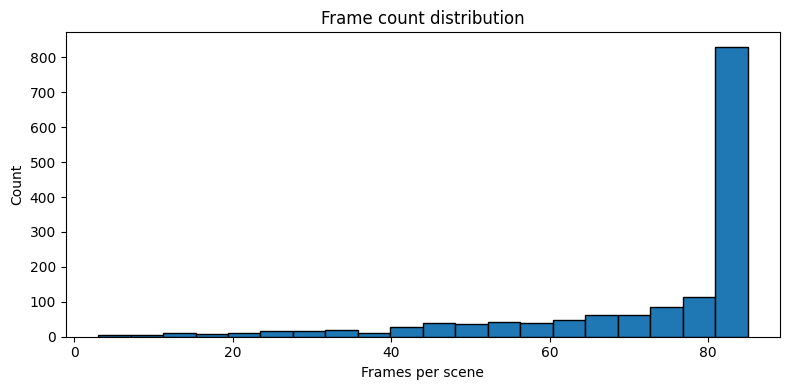


=== Depth range stats (sample of 100 frames) ===
  Min depth (non-zero, mm): 327
  Max depth (mm):           9414
  Mean zero fraction:       0.106


In [15]:
# Per-class frame counts
for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    if not os.path.exists(split_dir):
        continue
    print(f'\n=== {split.upper()} ===')
    total = 0
    class_counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        n = len(glob.glob(os.path.join(cls_dir, '*_rgb.pt')))
        class_counts[cls] = n
        total += n
    for cls, n in sorted(class_counts.items()):
        pct = 100.0 * n / total if total > 0 else 0
        print(f'  {cls:30s} {n:5d}  ({pct:5.1f}%)')
    print(f'  {"TOTAL":30s} {total:5d}')

# Frames per scene histogram
scene_frame_counts = Counter()
for split in ['train', 'val']:
    split_dir = os.path.join(BASE_OUT_DIR, split)
    if not os.path.exists(split_dir):
        continue
    for cls in os.listdir(split_dir):
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            if f.endswith('_rgb.pt'):
                match = re.match(r'(scene\d+_\d+)_f\d+_rgb\.pt', f)
                if match:
                    scene_frame_counts[match.group(1)] += 1

frame_counts = list(scene_frame_counts.values())
if frame_counts:
    print(f'\n=== Frames per scene ===')
    print(f'  Scenes: {len(frame_counts)}')
    print(f'  Min:    {min(frame_counts)}')
    print(f'  Max:    {max(frame_counts)}')
    print(f'  Mean:   {np.mean(frame_counts):.1f}')
    print(f'  Median: {np.median(frame_counts):.1f}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(frame_counts, bins=20, edgecolor='black')
    ax.set_xlabel('Frames per scene')
    ax.set_ylabel('Count')
    ax.set_title('Frame count distribution')
    plt.tight_layout()
    plt.show()

# Depth range stats (sample)
print(f'\n=== Depth range stats (sample of 100 frames) ===')
depth_files = glob.glob(os.path.join(BASE_OUT_DIR, 'train', '*', '*_depth.pt'))
random.shuffle(depth_files)
sample_depth = depth_files[:100]

assert sample_depth, (
    f'No depth files found in {os.path.join(BASE_OUT_DIR, "train", "*", "*_depth.pt")}. '
    f'Processing failed or has not been run yet.'
)
if True:
    depth_mins = []
    depth_maxs = []
    zero_fracs = []
    for dp in sample_depth:
        d = torch.load(dp, weights_only=True).float()
        if (d > 0).any():
            depth_mins.append(d[d > 0].min().item())
        depth_maxs.append(d.max().item())
        zero_fracs.append((d == 0).float().mean().item())

    if depth_mins:
        print(f'  Min depth (non-zero, mm): {np.min(depth_mins):.0f}')
    print(f'  Max depth (mm):           {np.max(depth_maxs):.0f}')
    print(f'  Mean zero fraction:       {np.mean(zero_fracs):.3f}')

## 15. Normalization Stats

Streaming (Welford) computation of RGB mean/std and depth mean/std
from **train split only**. Depth stats exclude pixels with value 0
(sentinel for missing data). Depth values are converted to meters
(`/ 1000.0`) before stats computation.

In [16]:
print('Scanning per-sample files from train split...')

all_rgb_paths = sorted(glob.glob(
    os.path.join(BASE_OUT_DIR, 'train', '*', '*_rgb.pt')
))
all_depth_paths = [p.replace('_rgb.pt', '_depth.pt') for p in all_rgb_paths]

print(f'Train samples: {len(all_rgb_paths)}')

# Welford online mean/variance
# RGB: per-channel (3 channels)
rgb_n = 0
rgb_mean = np.zeros(3, dtype=np.float64)
rgb_m2 = np.zeros(3, dtype=np.float64)

# Depth: single channel, excluding zeros
depth_n = 0
depth_mean = np.float64(0.0)
depth_m2 = np.float64(0.0)

for i, (rp, dp) in enumerate(tqdm(
    zip(all_rgb_paths, all_depth_paths),
    total=len(all_rgb_paths), desc='Computing stats'
)):
    # RGB: uint8 [3, H, W] -> float [0, 255]
    rgb = torch.load(rp, weights_only=True).numpy().astype(np.float64)
    # Per-pixel per-channel values
    for c in range(3):
        pixels = rgb[c].ravel()
        for val in pixels:
            rgb_n += 1
            delta = val - rgb_mean[c]
            rgb_mean[c] += delta / rgb_n
            delta2 = val - rgb_mean[c]
            rgb_m2[c] += delta * delta2

    # Depth: uint16 [1, H, W] -> meters (float64)
    depth_raw = torch.load(dp, weights_only=True).numpy().astype(np.float64)
    depth_meters = depth_raw.ravel() / 1000.0
    valid_mask = depth_raw.ravel() > 0
    valid_depths = depth_meters[valid_mask]

    for val in valid_depths:
        depth_n += 1
        delta = val - depth_mean
        depth_mean += delta / depth_n
        delta2 = val - depth_mean
        depth_m2 += delta * delta2

# Finalize
rgb_std = np.sqrt(rgb_m2 / (rgb_n - 1)) if rgb_n > 1 else np.zeros(3)
depth_std = np.sqrt(depth_m2 / (depth_n - 1)) if depth_n > 1 else 0.0

# Convert RGB from [0,255] to [0,1] range
rgb_mean_01 = rgb_mean / 255.0
rgb_std_01 = rgb_std / 255.0

norm_stats = {
    'rgb_mean': rgb_mean_01.tolist(),
    'rgb_std': rgb_std_01.tolist(),
    'depth_mean': [float(depth_mean)],
    'depth_std': [float(depth_std)],
}

print(f'\nRGB mean:   {rgb_mean_01}')
print(f'RGB std:    {rgb_std_01}')
print(f'Depth mean: {depth_mean:.4f} m')
print(f'Depth std:  {depth_std:.4f} m')
print(f'RGB pixels: {rgb_n:,}')
print(f'Depth pixels (non-zero): {depth_n:,}')

Scanning per-sample files from train split...
Train samples: 86080


Computing stats:   0%|          | 0/86080 [00:00<?, ?it/s]


RGB mean:   [0.52846588 0.46939917 0.39932327]
RGB std:    [0.16663539 0.16180827 0.15797056]
Depth mean: 1.8982 m
Depth std:  0.8237 m
RGB pixels: 16,924,016,640
Depth pixels (non-zero): 5,053,235,646


## 16. Write Metadata Files

In [17]:
# class_names.txt
class_names_path = os.path.join(BASE_OUT_DIR, 'class_names.txt')
with open(class_names_path, 'w') as f:
    for name in SCANNET_SCENE_TYPES:
        f.write(f'{name}\n')
print(f'Wrote {class_names_path} ({len(SCANNET_SCENE_TYPES)} classes)')

# norm_stats.json
norm_stats_path = os.path.join(BASE_OUT_DIR, 'norm_stats.json')
with open(norm_stats_path, 'w') as f:
    json.dump(norm_stats, f, indent=2)
print(f'Wrote {norm_stats_path}')

# dataset_info.txt
train_count = len(glob.glob(os.path.join(BASE_OUT_DIR, 'train', '*', '*_rgb.pt')))
val_count = len(glob.glob(os.path.join(BASE_OUT_DIR, 'val', '*', '*_rgb.pt')))

info_path = os.path.join(BASE_OUT_DIR, 'dataset_info.txt')
with open(info_path, 'w') as f:
    f.write('ScanNet Pretrain Dataset (256x256)\n')
    f.write(f'Created: {time.strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Num classes: {len(SCANNET_SCENE_TYPES)}\n')
    f.write(f'Train samples: {train_count}\n')
    f.write(f'Val samples: {val_count}\n')
    f.write(f'Total samples: {train_count + val_count}\n')
    f.write(f'Frames per scene: {FRAMES_PER_SCENE}\n')
    f.write(f'Target size: {TARGET_SIZE}\n')
    f.write(f'RGB format: uint8 [3, {TARGET_SIZE}, {TARGET_SIZE}]\n')
    f.write(f'Depth format: uint16 [1, {TARGET_SIZE}, {TARGET_SIZE}] (mm)\n')
    f.write(f'Depth stats: exclude zero sentinels, meters (/1000.0)\n')
    f.write(f'\nNorm stats:\n')
    for k, v in norm_stats.items():
        f.write(f'  {k}: {v}\n')
    f.write(f'\nClass names:\n')
    for i, name in enumerate(SCANNET_SCENE_TYPES):
        f.write(f'  {i}: {name}\n')
print(f'Wrote {info_path}')

Wrote /content/scannet_pretrain_256/class_names.txt (20 classes)
Wrote /content/scannet_pretrain_256/norm_stats.json
Wrote /content/scannet_pretrain_256/dataset_info.txt


## 17. ScanNet vs SUN RGB-D Comparison

Validates that ScanNet is suitable pretraining data for a model that will
fine-tune on SUN RGB-D. Compares normalization statistics, depth distributions,
missing-data ratios, and class overlap.

**Requires:** `sunrgbd_19_traintest.tar.gz` on Drive (copies only `norm_stats.json`,
`class_names.txt`, and a sample of tensors -- does NOT extract the full dataset).

In [18]:
# =========================================================================
# ScanNet vs SUN RGB-D -- Pretraining Fitness Check
# =========================================================================
# NOTE: SUN RGB-D uses a different storage format:
#   - Monolithic tensors: train/rgb_tensors.pt [N,3,256,256] uint8
#   - Depth is uint8 (0-254, NOT uint16 mm like ScanNet)
#   - norm_stats.json depth values are in uint8/255 space, not meters
# =========================================================================

SUN_TAR = '/content/drive/MyDrive/datasets/sunrgbd_19_traintest.tar.gz'
SUN_TMP = '/content/sun_comparison_tmp'

if not os.path.exists(SUN_TAR):
    print(f'WARNING: SUN RGB-D archive not found at {SUN_TAR}')
    print('Skipping comparison. Upload the archive to run this cell.')
else:
    os.makedirs(SUN_TMP, exist_ok=True)

    # Extract metadata + a sample of data
    subprocess.run([
        'tar', 'xzf', SUN_TAR, '-C', SUN_TMP,
        '--wildcards', '*/norm_stats.json', '*/class_names.txt',
        '*/train/depth_tensors.pt', '*/train/labels.txt',
    ], check=True, capture_output=True)

    # Find the extracted root
    sun_root = SUN_TMP
    for root, dirs, files in os.walk(SUN_TMP):
        if 'norm_stats.json' in files:
            sun_root = root
            break

    with open(os.path.join(sun_root, 'norm_stats.json')) as f:
        sun_stats = json.load(f)
    with open(os.path.join(sun_root, 'class_names.txt')) as f:
        sun_classes = [l.strip().split(': ', 1)[-1] for l in f if l.strip()]

    # SUN depth is uint8 (0-254). Its norm_stats are in uint8/255 space.
    # Convert to meters for comparison: SUN stores depth as uint8 where
    # the original range was mapped to 0-254. We need to understand the
    # actual depth range to compare meaningfully.
    sun_depth_in_meters = False  # Flag: are SUN depth stats in meters?
    if sun_stats['depth_mean'][0] < 1.0:
        print('NOTE: SUN depth stats appear to be in normalized (0-1) space, not meters.')
        print('      Direct depth comparison with ScanNet (meters) is not meaningful.')
        print('      RGB comparison is still valid.\n')
        sun_depth_in_meters = False
    else:
        sun_depth_in_meters = True

    # =====================================================================
    # 1. Normalization Statistics Comparison (RGB only if depth units differ)
    # =====================================================================
    print('=' * 70)
    print('1. NORMALIZATION STATISTICS COMPARISON')
    print('=' * 70)
    print(f'{"":30s} {"ScanNet":>15s} {"SUN RGB-D":>15s} {"Diff":>10s}')
    print('-' * 70)

    for ch, name in enumerate(['R', 'G', 'B']):
        sc = norm_stats['rgb_mean'][ch]
        su = sun_stats['rgb_mean'][ch]
        print(f'  RGB mean ({name})               {sc:15.4f} {su:15.4f} {abs(sc-su):10.4f}')
    for ch, name in enumerate(['R', 'G', 'B']):
        sc = norm_stats['rgb_std'][ch]
        su = sun_stats['rgb_std'][ch]
        print(f'  RGB std  ({name})               {sc:15.4f} {su:15.4f} {abs(sc-su):10.4f}')

    if sun_depth_in_meters:
        sc_dm = norm_stats['depth_mean'][0]
        su_dm = sun_stats['depth_mean'][0]
        sc_ds = norm_stats['depth_std'][0]
        su_ds = sun_stats['depth_std'][0]
        print(f'  Depth mean (m)               {sc_dm:15.4f} {su_dm:15.4f} {abs(sc_dm-su_dm):10.4f}')
        print(f'  Depth std  (m)               {sc_ds:15.4f} {su_ds:15.4f} {abs(sc_ds-su_ds):10.4f}')
    else:
        print(f'  Depth mean                   {norm_stats["depth_mean"][0]:15.4f} {sun_stats["depth_mean"][0]:15.4f}   (different units)')
        print(f'  Depth std                    {norm_stats["depth_std"][0]:15.4f} {sun_stats["depth_std"][0]:15.4f}   (different units)')

    # Flag divergences
    rgb_mean_diff = max(abs(norm_stats['rgb_mean'][i] - sun_stats['rgb_mean'][i]) for i in range(3))
    rgb_std_diff = max(abs(norm_stats['rgb_std'][i] - sun_stats['rgb_std'][i]) for i in range(3))

    print()
    if rgb_mean_diff < 0.05:
        print('  RGB mean: GOOD (< 0.05 divergence)')
    elif rgb_mean_diff < 0.10:
        print(f'  RGB mean: ACCEPTABLE ({rgb_mean_diff:.3f} divergence)')
    else:
        print(f'  RGB mean: WARNING -- large divergence ({rgb_mean_diff:.3f})')

    if rgb_std_diff < 0.05:
        print('  RGB std:  GOOD (< 0.05 divergence)')
    elif rgb_std_diff < 0.10:
        print(f'  RGB std:  ACCEPTABLE ({rgb_std_diff:.3f} divergence)')
    else:
        print(f'  RGB std:  WARNING -- large divergence ({rgb_std_diff:.3f})')

    # =====================================================================
    # 2. Class Overlap Analysis
    # =====================================================================
    print()
    print('=' * 70)
    print('2. CLASS OVERLAP ANALYSIS')
    print('=' * 70)

    scannet_classes_lower = {c.lower().replace(' ', '_').replace('/', '_') for c in SCANNET_SCENE_TYPES}
    sun_classes_lower = {c.lower().replace(' ', '_') for c in sun_classes}

    overlap = scannet_classes_lower & sun_classes_lower
    scannet_only = scannet_classes_lower - sun_classes_lower
    sun_only = sun_classes_lower - scannet_classes_lower

    print(f'  ScanNet classes:  {len(SCANNET_SCENE_TYPES)}')
    print(f'  SUN RGB-D classes: {len(sun_classes)}')
    print(f'  Exact overlap:    {len(overlap)}')
    if overlap:
        print(f'    Shared: {sorted(overlap)}')
    if scannet_only:
        print(f'    ScanNet only: {sorted(scannet_only)}')
    if sun_only:
        print(f'    SUN only: {sorted(sun_only)}')

    overlap_pct = len(overlap) / len(sun_classes_lower) * 100 if sun_classes_lower else 0
    if overlap_pct > 50:
        print(f'  Class overlap: GOOD ({overlap_pct:.0f}% of SUN classes covered)')
    else:
        print(f'  Class overlap: LOW ({overlap_pct:.0f}% of SUN classes covered)')
        print('  Note: Pretraining still helps even with low class overlap --')
        print('  the model learns general RGB-D spatial features, not just class-specific ones.')

    # =====================================================================
    # 3. Depth Distribution Comparison (ScanNet only if SUN units differ)
    # =====================================================================
    print()
    print('=' * 70)
    print('3. DEPTH DISTRIBUTION ANALYSIS')
    print('=' * 70)

    # ScanNet depth sample
    scannet_depth_sample = []
    scannet_zero_count = 0
    scannet_total_pixels = 0
    sample_paths = sorted(glob.glob(os.path.join(BASE_OUT_DIR, 'train', '*', '*_depth.pt')))[:500]
    for p in sample_paths:
        d = torch.load(p, weights_only=True).numpy().astype(np.float64).ravel()
        scannet_total_pixels += len(d)
        scannet_zero_count += (d == 0).sum()
        valid = d[d > 0] / 1000.0
        if len(valid) > 0:
            idx = np.random.choice(len(valid), min(200, len(valid)), replace=False)
            scannet_depth_sample.extend(valid[idx].tolist())
    scannet_depth_sample = np.array(scannet_depth_sample)

    sc_missing = scannet_zero_count / scannet_total_pixels * 100 if scannet_total_pixels > 0 else 0
    print(f'  ScanNet missing depth (zero pixels): {sc_missing:.2f}%')

    if len(scannet_depth_sample) > 0:
        print(f'  ScanNet depth range (m): [{scannet_depth_sample.min():.2f}, {scannet_depth_sample.max():.2f}]')
        print(f'    median={np.median(scannet_depth_sample):.2f}, '
              f'p5={np.percentile(scannet_depth_sample, 5):.2f}, '
              f'p95={np.percentile(scannet_depth_sample, 95):.2f}')

    # SUN depth sample (uint8, load from monolithic tensor)
    sun_depth_path = os.path.join(sun_root, 'train', 'depth_tensors.pt')
    if os.path.exists(sun_depth_path):
        sun_depth_all = torch.load(sun_depth_path, weights_only=True)
        # Sample 500 frames
        n_sun = min(500, sun_depth_all.shape[0])
        sun_sample_idx = np.random.choice(sun_depth_all.shape[0], n_sun, replace=False)
        sun_depth_sample_raw = sun_depth_all[sun_sample_idx].numpy().astype(np.float64)

        sun_total_pixels = sun_depth_sample_raw.size
        sun_zero_count = (sun_depth_sample_raw == 0).sum()
        su_missing = sun_zero_count / sun_total_pixels * 100

        print(f'  SUN missing depth (zero pixels):    {su_missing:.2f}%')
        print(f'  SUN depth dtype: {sun_depth_all.dtype} (range 0-{sun_depth_all.to(torch.int32).max().item()})')

        if sc_missing > 0 and su_missing > 0:
            ratio = sc_missing / su_missing
            if ratio > 3:
                print(f'  WARNING: ScanNet has {ratio:.1f}x more missing depth')
            else:
                print(f'  Missing depth ratios are comparable')
        elif su_missing == 0 and sc_missing > 5:
            print(f'  NOTE: SUN has no missing depth; ScanNet has {sc_missing:.1f}%')
            print(f'  This is expected -- ScanNet is real sensor data with occlusions')

        del sun_depth_all  # Free memory
    else:
        print(f'  SUN depth tensors not found (skipping depth comparison)')
        su_missing = 0

    # =====================================================================
    # 4. Depth Histogram (ScanNet only)
    # =====================================================================
    print()
    print('=' * 70)
    print('4. DEPTH HISTOGRAM')
    print('=' * 70)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    if len(scannet_depth_sample) > 0:
        bins = np.linspace(0, 10, 100)
        ax.hist(scannet_depth_sample, bins=bins, alpha=0.7, color='steelblue',
                density=True, edgecolor='black', linewidth=0.5)
        ax.set_xlabel('Depth (meters)')
        ax.set_ylabel('Density')
        ax.set_title('ScanNet Depth Distribution')
        ax.set_xlim(0, 8)
        ax.axvline(norm_stats['depth_mean'][0], color='red', linestyle='--',
                   label=f'mean={norm_stats["depth_mean"][0]:.2f}m')
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_OUT_DIR, 'scannet_depth_distribution.png'), dpi=150)
    plt.show()

    # =====================================================================
    # 5. Dataset Scale Comparison
    # =====================================================================
    print()
    print('=' * 70)
    print('5. DATASET SCALE COMPARISON')
    print('=' * 70)

    scannet_train = sum(1 for _ in glob.glob(os.path.join(BASE_OUT_DIR, 'train', '*', '*_rgb.pt')))
    scannet_val = sum(1 for _ in glob.glob(os.path.join(BASE_OUT_DIR, 'val', '*', '*_rgb.pt')))

    # SUN uses monolithic tensors — count from labels.txt
    sun_labels_path = os.path.join(sun_root, 'train', 'labels.txt')
    if os.path.exists(sun_labels_path):
        with open(sun_labels_path) as f:
            sun_train = sum(1 for line in f if line.strip())
    else:
        sun_train = 0

    print(f'  ScanNet train samples: {scannet_train:,}')
    print(f'  ScanNet val samples:   {scannet_val:,}')
    print(f'  ScanNet total:         {scannet_train + scannet_val:,}')
    print(f'  SUN RGB-D train:       {sun_train:,}')
    if sun_train > 0:
        ratio = (scannet_train + scannet_val) / sun_train
        print(f'  ScanNet/SUN ratio:     {ratio:.1f}x')
        if ratio >= 5:
            print(f'  Scale: EXCELLENT -- ScanNet is {ratio:.0f}x larger')
        elif ratio >= 2:
            print(f'  Scale: GOOD -- ScanNet is {ratio:.0f}x larger')
        else:
            print(f'  Scale: MARGINAL -- pretraining data ideally 5-10x larger')
    else:
        print(f'  SUN train count not available')

    # =====================================================================
    # 6. Summary Verdict
    # =====================================================================
    print()
    print('=' * 70)
    print('6. PRETRAINING FITNESS SUMMARY')
    print('=' * 70)

    issues = []
    if rgb_mean_diff > 0.10:
        issues.append(f'Large RGB mean divergence ({rgb_mean_diff:.3f})')
    if rgb_std_diff > 0.15:
        issues.append(f'Large RGB std divergence ({rgb_std_diff:.3f})')
    if sc_missing > 20:
        issues.append(f'High ScanNet missing depth ({sc_missing:.1f}%)')

    if not issues:
        print('  VERDICT: ScanNet is well-suited for pretraining on SUN RGB-D')
        print('  - RGB distributions are compatible')
        print('  - Sufficient scale for transfer learning')
    else:
        print('  VERDICT: Review the following concerns:')
        for issue in issues:
            print(f'    - {issue}')
        print('  These may not be blockers -- pretraining often helps even with')
        print('  distribution differences, as the model learns general features.')

    # Clean up
    shutil.rmtree(SUN_TMP, ignore_errors=True)
    print(f'\n  Cleaned up {SUN_TMP}')

## 18. Spot Check

Visualize random samples from each class with matplotlib (RGB + depth
side by side).

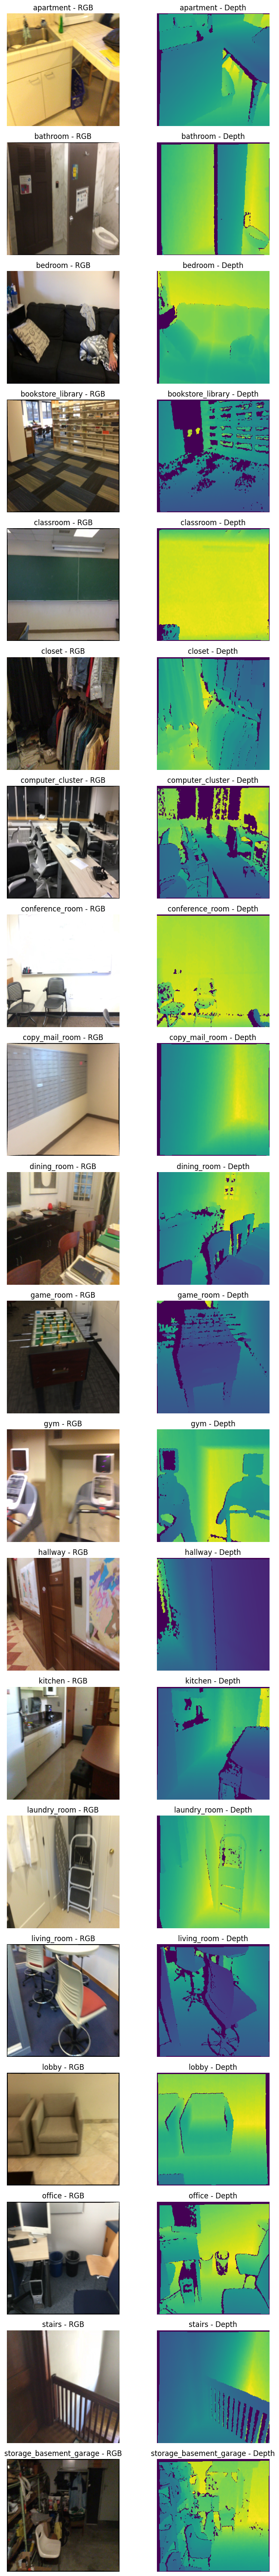

In [19]:
random.seed(42)

# Pick one random sample per class from train split
fig, axes = plt.subplots(
    len(SCANNET_SCENE_TYPES), 2,
    figsize=(8, 3 * len(SCANNET_SCENE_TYPES))
)

for i, cls in enumerate(SCANNET_SCENE_TYPES):
    cls_dir = os.path.join(BASE_OUT_DIR, 'train', cls)
    rgb_files = sorted(glob.glob(os.path.join(cls_dir, '*_rgb.pt')))

    if not rgb_files:
        axes[i, 0].set_title(f'{cls} (no samples)')
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
        continue

    chosen = random.choice(rgb_files)
    depth_path = chosen.replace('_rgb.pt', '_depth.pt')

    rgb = torch.load(chosen, weights_only=True).numpy().transpose(1, 2, 0)
    depth = torch.load(depth_path, weights_only=True).numpy().squeeze()

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f'{cls} - RGB')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(depth, cmap='viridis')
    axes[i, 1].set_title(f'{cls} - Depth')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 19. Package & Upload to Drive

In [20]:
local_tar = '/content/ScanNet_Pretrain_256.tar.gz'

print('Creating tar.gz...')
print('This may take a while for ~34GB of data.')

subprocess.run([
    'tar', 'czf', local_tar,
    '-C', os.path.dirname(BASE_OUT_DIR),
    os.path.basename(BASE_OUT_DIR),
], check=True)

tar_size = os.path.getsize(local_tar) / (1024 ** 3)
print(f'Archive size: {tar_size:.2f} GB')

# Copy to Drive
drive_dest = os.path.join(DRIVE, 'scannet_pretrain_256.tar.gz')
print(f'Copying to {drive_dest}...')
shutil.copy2(local_tar, drive_dest)
print('Done!')

# Verify
drive_size = os.path.getsize(drive_dest) / (1024 ** 3)
print(f'Drive archive size: {drive_size:.2f} GB')

Creating tar.gz...
This may take a while for ~34GB of data.
Archive size: 19.14 GB
Copying to /content/drive/MyDrive/data/scannet_pretrain_256.tar.gz...
Done!
Drive archive size: 19.14 GB
